<a href="https://colab.research.google.com/github/muhardan/Tugas-Praktikum-1-AI/blob/main/linear_sederhana_tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [12]:
# 1. BUAT DATA SENDIRI: Biaya Iklan vs Penjualan
data = {
    'biaya_iklan_juta': [2, 3, 4, 5.5, 6, 7.5, 8, 9.5, 10, 12],
    'penjualan_unit': [150, 200, 250, 310, 330, 420, 450, 510, 530, 600]
}

df = pd.DataFrame(data)
print("--- Data Penjualan ---")
print(df)
print("\n")

--- Data Penjualan ---
   biaya_iklan_juta  penjualan_unit
0               2.0             150
1               3.0             200
2               4.0             250
3               5.5             310
4               6.0             330
5               7.5             420
6               8.0             450
7               9.5             510
8              10.0             530
9              12.0             600




In [13]:
X = df[['biaya_iklan_juta']]  # fitur (harus 2D)
y = df['penjualan_unit']      # target

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b):", model.coef_[0])

Intercept (a): 63.07692307692304
Koefisien (b): 46.15384615384616


In [17]:
y_pred = model.predict(X_test)

print("\n--- Data Testing ---")
print(X_test)
print("Penjualan Asli:", y_test.values)
print("Penjualan Prediksi:", y_pred)


--- Data Testing ---
   biaya_iklan_juta
8              10.0
1               3.0
Penjualan Asli: [530 200]
Penjualan Prediksi: [524.61538462 201.53846154]


In [18]:
print("\n--- Evaluasi Model ---")
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


--- Evaluasi Model ---
MAE: 3.4615384615384386
MSE: 15.680473372780895
RMSE: 3.9598577465334404


In [19]:
prediksi = model.predict([[15]])
print(f"\nPrediksi penjualan untuk biaya iklan 15 juta: {prediksi[0]:.2f} unit")


Prediksi penjualan untuk biaya iklan 15 juta: 755.38 unit


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [20]:
# ANALISIS
print("\n=======================================================")
print("ANALISIS REGRESI LINEAR SEDERHANA:")
print("1. Nilai Koefisien (b) yang positif menunjukkan hubungan searah: Semakin besar biaya iklan, semakin tinggi penjualan produk.")
print("2. Nilai error (RMSE) relatif kecil dibandingkan skala data ratusan unit, menandakan model cukup akurat.")
print("3. Model ini berguna bagi perusahaan untuk memprediksi stok barang jika budget iklan dinaikkan.")
print("=======================================================")


ANALISIS REGRESI LINEAR SEDERHANA:
1. Nilai Koefisien (b) yang positif menunjukkan hubungan searah: Semakin besar biaya iklan, semakin tinggi penjualan produk.
2. Nilai error (RMSE) relatif kecil dibandingkan skala data ratusan unit, menandakan model cukup akurat.
3. Model ini berguna bagi perusahaan untuk memprediksi stok barang jika budget iklan dinaikkan.


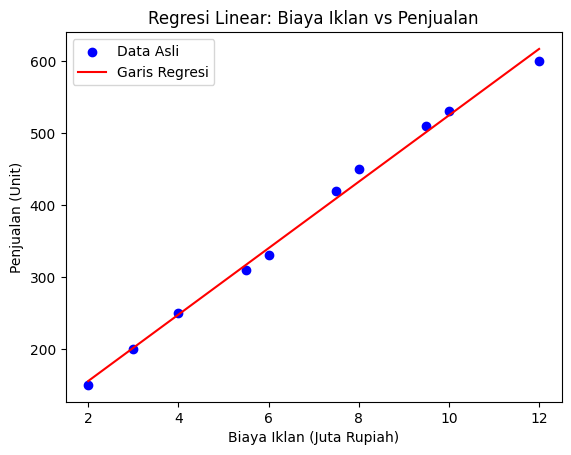

In [21]:
plt.scatter(X, y, label="Data Asli", color='blue')
plt.plot(X, model.predict(X), label="Garis Regresi", color='red')
plt.xlabel("Biaya Iklan (Juta Rupiah)")
plt.ylabel("Penjualan (Unit)")
plt.title("Regresi Linear: Biaya Iklan vs Penjualan")
plt.legend()
plt.show()